# Smart Document Scanner - Demo & Testing

**Proyek UAS Visi Komputer**

Aplikasi pemindai dokumen pintar dengan berbagai fitur Computer Vision:
- 📐 Edge Detection & Boundary Detection
- 🖼️ Filtering & Image Enhancement  
- 🔄 Perspective Correction
- ✂️ Seam Carving untuk Object Removal
- 📹 Real-time Document Tracking
- 🤖 Automated Pipeline

---

## 1. Import Libraries dan Setup

In [1]:
# Import standard libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from importlib import reload

# Add modules to path
sys.path.insert(0, str(Path.cwd()))

# Import custom modules
from modules import boundary_detector, image_enhancer, perspective_corrector, seam_carver, document_tracker, utils

# Reload modules (helpful during development)
reload(boundary_detector)
reload(image_enhancer)
reload(perspective_corrector)
reload(seam_carver)
reload(document_tracker)
reload(utils)

from modules.boundary_detector import DocumentDetector
from modules.image_enhancer import ImageEnhancer
from modules.perspective_corrector import PerspectiveCorrector
from modules.seam_carver import SeamCarver
from modules.document_tracker import DocumentTracker
from modules.utils import display_images, load_image, save_image

# Setup matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 5)

print("✅ All libraries imported successfully!")
print(f"📁 Working directory: {Path.cwd()}")

✅ All libraries imported successfully!
📁 Working directory: /home/glennhkm/Documents/Viskom/MK/UAS


## 2. Create Sample Document Image

Karena kita belum memiliki sample image, mari buat sample document sederhana untuk testing:

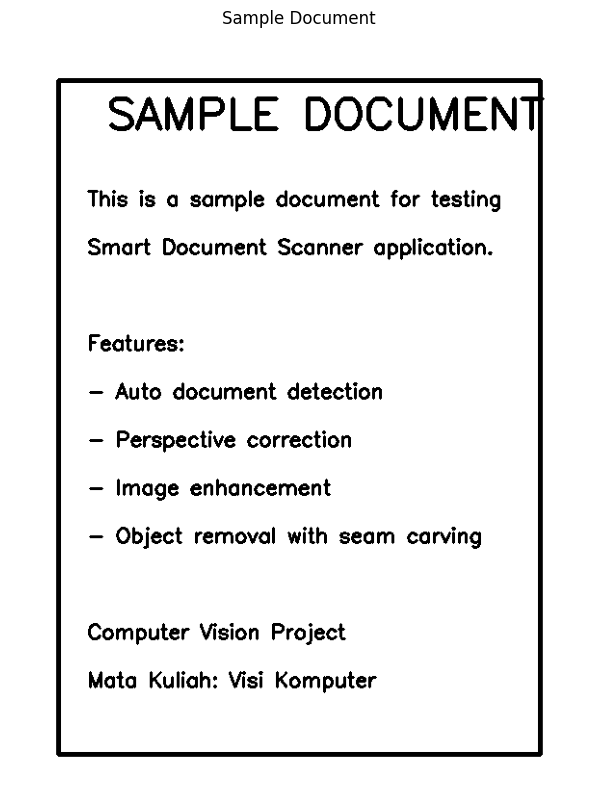

✅ Sample document created!


In [7]:
# Create sample document image
def create_sample_document():
    """Create a sample document with text for testing"""
    # Create white background
    img = np.ones((800, 600, 3), dtype=np.uint8) * 255
    
    # Add title
    cv2.putText(img, "SAMPLE DOCUMENT", (100, 100), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 3)
    
    # Add some text lines
    texts = [
        "This is a sample document for testing",
        "Smart Document Scanner application.",
        "",
        "Features:",
        "- Auto document detection",
        "- Perspective correction",
        "- Image enhancement",
        "- Object removal with seam carving",
        "",
        "Computer Vision Project",
        "Mata Kuliah: Visi Komputer"
    ]
    
    y = 180
    for text in texts:
        cv2.putText(img, text, (80, y), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
        y += 50
    
    # Add border
    cv2.rectangle(img, (50, 50), (550, 750), (0, 0, 0), 3)
    
    return img

# Create and save sample document
sample_doc = create_sample_document()
save_image(sample_doc, 'sample_images/document1.jpg')

# sample_path = "sample_images/sample_1.jpeg"
# sample_doc = cv2.imread(sample_path)

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(sample_doc, cv2.COLOR_BGR2RGB))
plt.title("Sample Document")
plt.axis('off')
plt.show()

print("✅ Sample document created!")

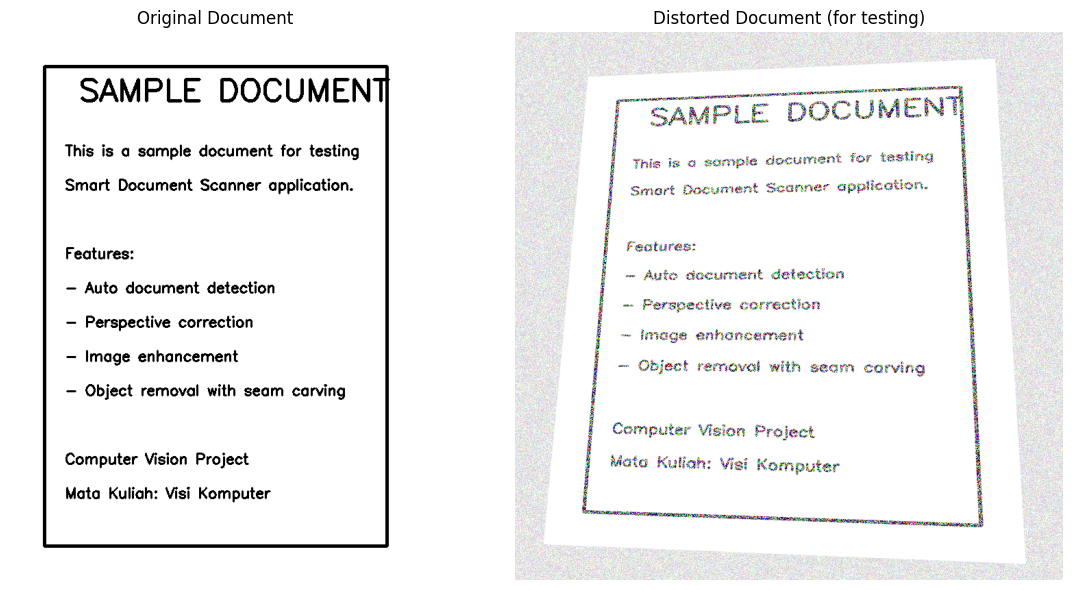

✅ Distorted document created!


In [8]:
# Create a perspective-distorted version for testing detection
def create_distorted_document(original):
    """Create a perspective-distorted version of document"""
    h, w = original.shape[:2]
    
    # Define source and destination points for perspective transform
    # Source: original rectangle
    src = np.float32([
        [50, 50],      # top-left
        [550, 50],     # top-right
        [550, 750],    # bottom-right
        [50, 750]      # bottom-left
    ])
    
    # Destination: distorted quadrilateral (simulate photo from angle)
    dst = np.float32([
        [150, 100],    # top-left moved
        [650, 80],     # top-right moved
        [680, 720],    # bottom-right moved
        [100, 700]     # bottom-left moved
    ])
    
    # Get perspective transform matrix
    M = cv2.getPerspectiveTransform(src, dst)
    
    # Apply transformation with larger canvas
    distorted = cv2.warpPerspective(original, M, (800, 800), 
                                    borderMode=cv2.BORDER_CONSTANT,
                                    borderValue=(200, 200, 200))
    
    # Add some noise
    noise = np.random.normal(0, 10, distorted.shape).astype(np.uint8)
    distorted = cv2.add(distorted, noise)
    
    return distorted

# Create distorted version
distorted_doc = create_distorted_document(sample_doc)
save_image(distorted_doc, 'sample_images/document_distorted.jpg')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sample_doc, cv2.COLOR_BGR2RGB))
plt.title("Original Document")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(distorted_doc, cv2.COLOR_BGR2RGB))
plt.title("Distorted Document (for testing)")
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Distorted document created!")

## 3. Test Edge Detection & Boundary Detection

Menggunakan **Canny Edge Detection** dan **Contour Detection** untuk menemukan batas dokumen.

In [4]:
# Initialize detector
detector = DocumentDetector()

# Load distorted image
test_image = load_image('sample_images/document_distorted.jpg')

# Get edge map untuk visualization
edge_map = detector.get_edge_map(test_image)

# Detect document corners
corners = detector.detect_document(test_image)

# Visualize detection
if corners is not None:
    detection_vis = detector.visualize_detection(test_image, corners)
    
    # Display results
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
    plt.title("1. Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(edge_map, cmap='gray')
    plt.title("2. Edge Detection (Canny)")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(detection_vis, cv2.COLOR_BGR2RGB))
    plt.title("3. Boundary Detection (4 Corners)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Document detected successfully!")
    print(f"📐 Detected corners:\n{corners}")
else:
    print("❌ Document not detected!")

❌ Document not detected!


## 4. Test Perspective Correction

Koreksi perspektif menggunakan **Homography** dan **4-point transformation**.

In [5]:
# Initialize corrector
corrector = PerspectiveCorrector()

if corners is not None:
    # Correct perspective
    corrected = corrector.correct_perspective(test_image, corners)
    
    # Save result
    save_image(corrected, 'output/corrected_document.jpg')
    
    # Display comparison
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
    plt.title("Before: Distorted Document")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    plt.title("After: Perspective Corrected (Bird's Eye View)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Perspective correction completed!")
    print(f"📏 Original size: {test_image.shape[:2]}")
    print(f"📏 Corrected size: {corrected.shape[:2]}")
else:
    print("⚠️ Cannot correct perspective - no corners detected")

⚠️ Cannot correct perspective - no corners detected


## 5. Test Image Enhancement & Filtering

Berbagai teknik filtering untuk meningkatkan kualitas dokumen:
- Adaptive Thresholding
- Bilateral Filter
- CLAHE (Contrast Enhancement)
- Sharpening

In [6]:
# Initialize enhancer
enhancer = ImageEnhancer()

if corners is not None:
    # Test berbagai filter
    grayscale = enhancer.grayscale(corrected)
    adaptive_thresh = enhancer.adaptive_threshold(corrected, block_size=11, c=2)
    bilateral = enhancer.denoise_bilateral(corrected, d=9, sigma_color=75, sigma_space=75)
    clahe = enhancer.enhance_contrast(corrected, clip_limit=2.0)
    sharpened = enhancer.sharpen(corrected, kernel_type='standard')
    scan_effect = enhancer.document_scan_effect(corrected)
    
    # Save best result
    save_image(scan_effect, 'output/enhanced_document.jpg')
    
    # Display all enhancement results
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    results = [
        (corrected, "Original (Corrected)"),
        (grayscale, "Grayscale"),
        (adaptive_thresh, "Adaptive Threshold"),
        (bilateral, "Bilateral Filter"),
        (clahe, "CLAHE Enhancement"),
        (sharpened, "Sharpened"),
        (scan_effect, "Document Scan Effect"),
        (cv2.cvtColor(clahe, cv2.COLOR_GRAY2BGR), "CLAHE (Gray to BGR)")
    ]
    
    for idx, (img, title) in enumerate(results):
        row = idx // 4
        col = idx % 4
        
        if len(img.shape) == 2:  # Grayscale
            axes[row, col].imshow(img, cmap='gray')
        else:  # Color
            axes[row, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        
        axes[row, col].set_title(title, fontsize=12, fontweight='bold')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ All enhancement filters applied successfully!")
else:
    print("⚠️ Cannot enhance - no corrected image available")

⚠️ Cannot enhance - no corrected image available


## 6. Test Seam Carving

Demonstrasi **content-aware image resizing** menggunakan seam carving algorithm.

🔧 Applying seam carving...
   Original width: 585px
   Target width: 485px
   Seams to remove: 100


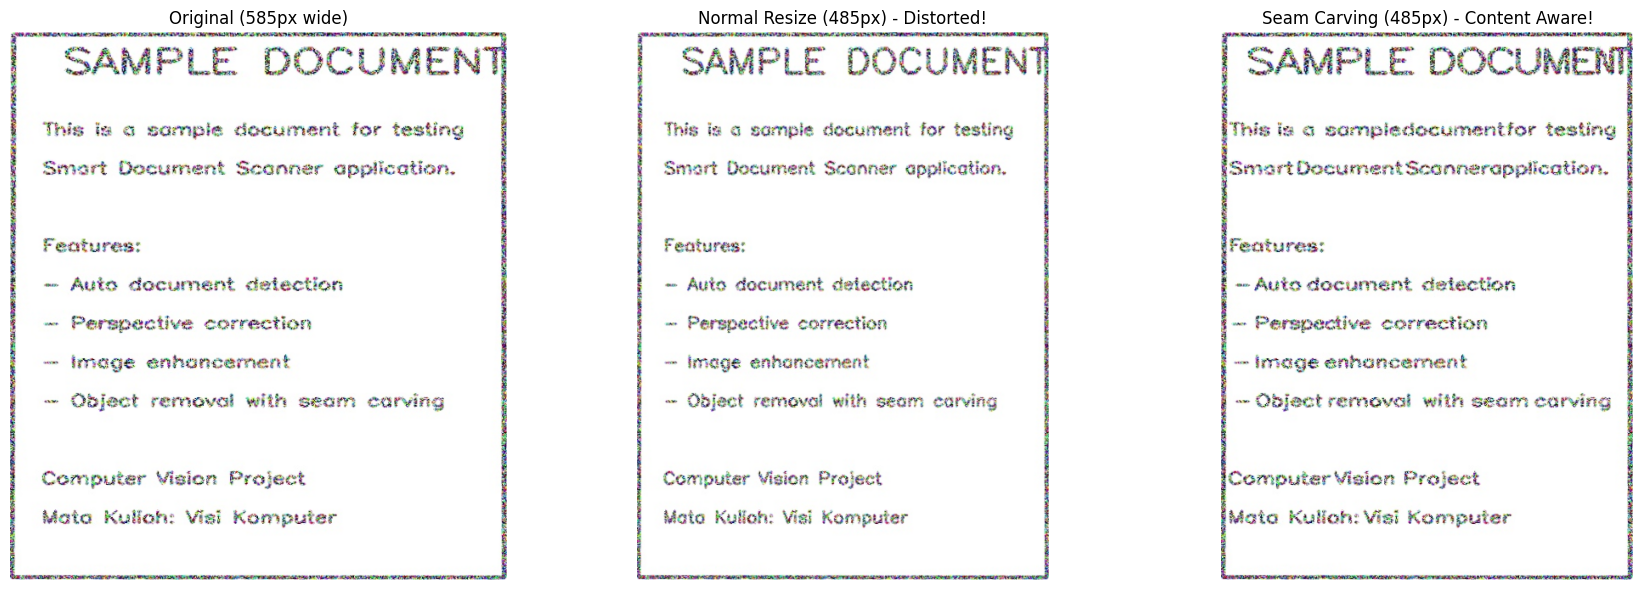

✅ Seam carving completed!
💡 Perhatikan: Seam carving mempertahankan konten penting!


In [14]:
# Initialize seam carver
carver = SeamCarver()

if corners is not None:
    # Use corrected image
    test_img = corrected.copy()
    original_width = test_img.shape[1]
    
    # Resize to smaller width (remove 100 pixels)
    target_width = original_width - 100
    
    print(f"🔧 Applying seam carving...")
    print(f"   Original width: {original_width}px")
    print(f"   Target width: {target_width}px")
    print(f"   Seams to remove: 100")
    
    # Apply seam carving (this may take a moment)
    carved = carver.resize_width(test_img, target_width)
    
    # Also resize using normal resize untuk comparison
    normal_resize = cv2.resize(test_img, (target_width, test_img.shape[0]))
    
    # Save result
    save_image(carved, 'output/seam_carved.jpg')
    
    # Display comparison
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original ({original_width}px wide)")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(normal_resize, cv2.COLOR_BGR2RGB))
    plt.title(f"Normal Resize ({target_width}px) - Distorted!")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(carved, cv2.COLOR_BGR2RGB))
    plt.title(f"Seam Carving ({target_width}px) - Content Aware!")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Seam carving completed!")
    print("💡 Perhatikan: Seam carving mempertahankan konten penting!")
else:
    print("⚠️ Cannot test seam carving - no corrected image")

## 7. Complete Pipeline Demo

Menjalankan complete pipeline dari raw image sampai enhanced document.

🚀 Starting Document Processing Pipeline...

📥 Step 1: Loading image...
   ✓ Image loaded: (800, 800, 3)

🔍 Step 2: Detecting document boundaries...
   ✓ Document detected with 4 corners

🔄 Step 3: Correcting perspective...
   ✓ Perspective corrected: (645, 585, 3)

✨ Step 4: Enhancing image quality...
   ✓ Enhancement completed

💾 Step 5: Saving results to output/...
   ✓ All results saved

✅ Pipeline completed successfully!


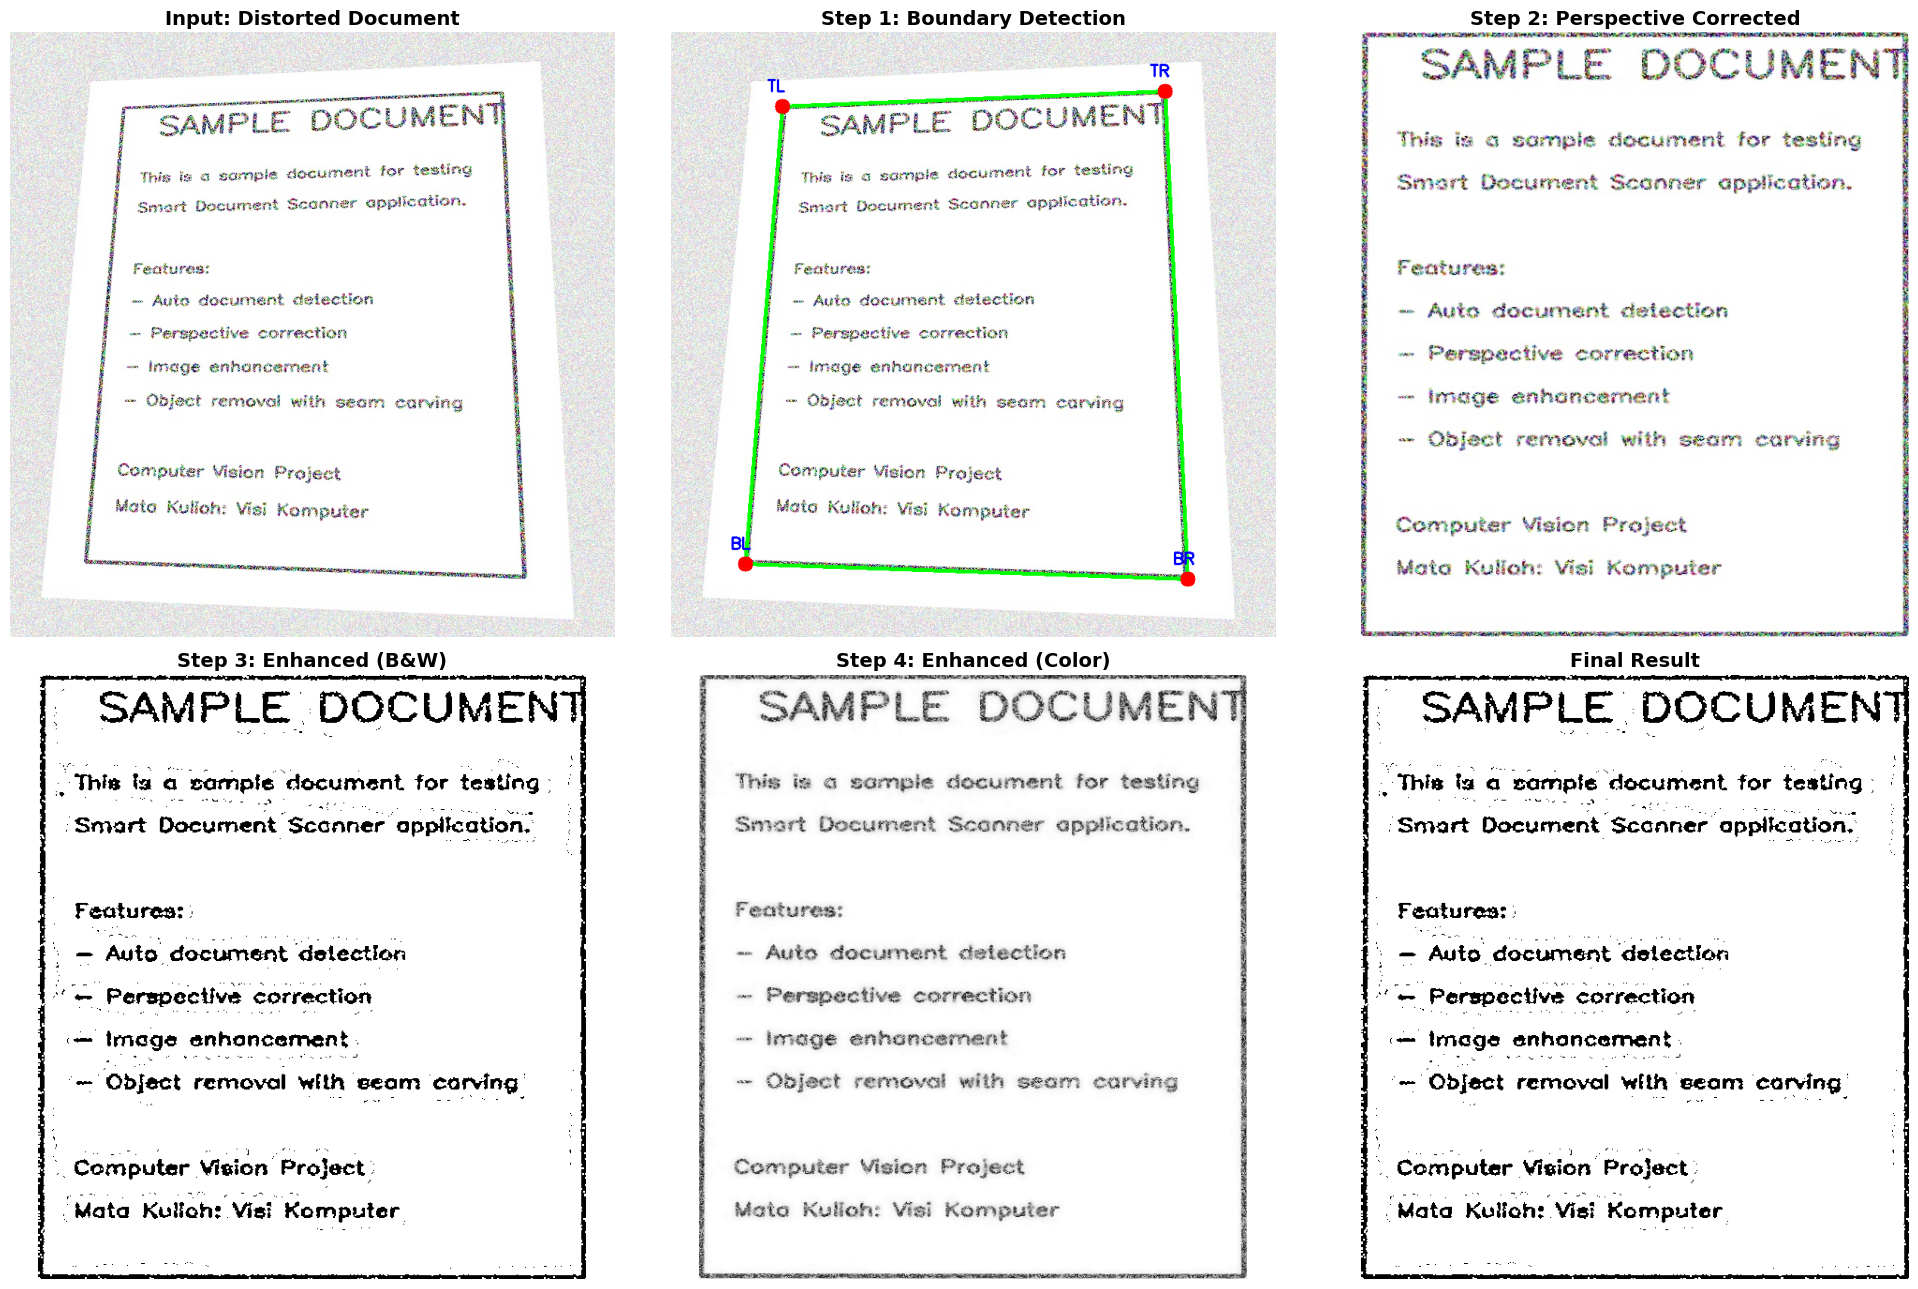

In [15]:
def process_document_pipeline(image_path, output_dir='output'):
    """
    Complete pipeline untuk memproses dokumen
    
    Steps:
    1. Load image
    2. Detect document boundaries (Edge Detection + Contour Detection)
    3. Correct perspective (Homography)
    4. Enhance image (Filtering)
    5. Save results
    """
    print("🚀 Starting Document Processing Pipeline...")
    print("=" * 60)
    
    # Step 1: Load image
    print("\n📥 Step 1: Loading image...")
    image = load_image(image_path)
    print(f"   ✓ Image loaded: {image.shape}")
    
    # Step 2: Detect document
    print("\n🔍 Step 2: Detecting document boundaries...")
    detector = DocumentDetector()
    corners = detector.detect_document(image)
    
    if corners is None:
        print("   ✗ Failed to detect document!")
        return None
    
    print(f"   ✓ Document detected with 4 corners")
    detection_vis = detector.visualize_detection(image, corners)
    
    # Step 3: Correct perspective
    print("\n🔄 Step 3: Correcting perspective...")
    corrector = PerspectiveCorrector()
    corrected = corrector.correct_perspective(image, corners)
    print(f"   ✓ Perspective corrected: {corrected.shape}")
    
    # Step 4: Enhance image
    print("\n✨ Step 4: Enhancing image quality...")
    enhancer = ImageEnhancer()
    
    # Create multiple enhanced versions
    enhanced_bw = enhancer.document_scan_effect(corrected)
    enhanced_color = enhancer.denoise_bilateral(corrected)
    enhanced_color = cv2.cvtColor(
        enhancer.enhance_contrast(cv2.cvtColor(enhanced_color, cv2.COLOR_BGR2GRAY)),
        cv2.COLOR_GRAY2BGR
    )
    
    print(f"   ✓ Enhancement completed")
    
    # Step 5: Save results
    print(f"\n💾 Step 5: Saving results to {output_dir}/...")
    Path(output_dir).mkdir(exist_ok=True)
    
    save_image(detection_vis, f'{output_dir}/1_detection.jpg')
    save_image(corrected, f'{output_dir}/2_corrected.jpg')
    save_image(enhanced_bw, f'{output_dir}/3_enhanced_bw.jpg')
    save_image(enhanced_color, f'{output_dir}/4_enhanced_color.jpg')
    
    print("   ✓ All results saved")
    
    print("\n" + "=" * 60)
    print("✅ Pipeline completed successfully!")
    
    return {
        'original': image,
        'detection': detection_vis,
        'corrected': corrected,
        'enhanced_bw': enhanced_bw,
        'enhanced_color': enhanced_color
    }

# Run pipeline
results = process_document_pipeline('sample_images/document_distorted.jpg')

# Display all results
if results:
    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    
    images_to_show = [
        (results['original'], 'Input: Distorted Document'),
        (results['detection'], 'Step 1: Boundary Detection'),
        (results['corrected'], 'Step 2: Perspective Corrected'),
        (results['enhanced_bw'], 'Step 3: Enhanced (B&W)'),
        (results['enhanced_color'], 'Step 4: Enhanced (Color)'),
        (results['enhanced_bw'], 'Final Result')
    ]
    
    for idx, (img, title) in enumerate(images_to_show):
        row = idx // 3
        col = idx % 3
        
        if len(img.shape) == 2:
            axes[row, col].imshow(img, cmap='gray')
        else:
            axes[row, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        
        axes[row, col].set_title(title, fontsize=14, fontweight='bold')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

## 8. Summary & Conclusion

### ✅ Fitur yang Telah Diimplementasikan:

1. **Edge Detection** - Canny edge detection untuk menemukan tepi
2. **Boundary Detection** - Contour detection dan polygon approximation
3. **Filtering** - Gaussian blur, bilateral filter, adaptive thresholding
4. **Perspective Correction** - Homography dan 4-point transformation
5. **Image Enhancement** - CLAHE, sharpening, denoising
6. **Seam Carving** - Content-aware resizing dengan dynamic programming
7. **Real-time Tracking** - Modul untuk webcam tracking (lihat modules/)

### 📚 Materi Computer Vision yang Digunakan:

- ✅ **Filtering** - Berbagai filter (Gaussian, Bilateral, etc.)
- ✅ **Edge Detection** - Canny algorithm
- ✅ **Boundary Detection** - Contour detection dengan OpenCV
- ✅ **Seam Carving** - Dynamic programming untuk content-aware resizing
- ✅ **Object Tracking** - Real-time tracking module tersedia
- ✅ **Ekstraksi Fitur** - Corner detection dan feature extraction

### 🎯 Aplikasi Praktis:

Aplikasi ini sangat berguna untuk:
- 📱 Mobile document scanning
- 📄 Digitalisasi dokumen fisik
- 🏢 Office automation
- 📚 Library document archival
- 🎓 Academic research

### 🚀 Cara Menggunakan:

**Option 1: Streamlit Web App**
```bash
streamlit run app.py
```

**Option 2: Python Script**
```python
from modules import DocumentDetector, PerspectiveCorrector, ImageEnhancer

detector = DocumentDetector()
corrector = PerspectiveCorrector()
enhancer = ImageEnhancer()

# Process image
corners = detector.detect_document(image)
corrected = corrector.correct_perspective(image, corners)
enhanced = enhancer.document_scan_effect(corrected)
```

**Option 3: Real-time Tracking**
```python
from modules import DocumentTracker

tracker = DocumentTracker()
tracker.track_document(auto_capture=True)
```

---

### 📝 Catatan untuk Pengembangan Lebih Lanjut:

1. Tambahkan OCR (Tesseract) untuk text extraction
2. Implementasi CNN untuk document classification
3. Tambahkan QR/Barcode detection
4. Multi-page PDF support
5. Cloud integration (Google Drive, Dropbox)

**Proyek ini mendemonstrasikan pemahaman komprehensif tentang Computer Vision dan implementasi praktisnya!** 🎓✨